# Level 3 — Imaging-Based Spatial Transcriptomics: Xenium

## CAJAL "Neuromics 2026" — Computational Mini-Project C10 (Level 3)

Welcome to Level 3. In Levels 1 and 2 you working with **snRNA-seq** (single nuclei) and
**Visium** (spatial *spots*). This notebook introduces a third, higher-resolution
technology: **10x Xenium**, an *imaging-based* spatial method that measures gene
expression in **true single cells, at subcellular resolution**.

This is a **working example**: unlike the Level 1/2 student notebooks, every code cell is
already filled in and ready to run. Read the explanation above each cell first, then run
the cell and look at the output. The 🔬 **TASK** / 💡 **HINT** / ❓ **QUESTION** markers
tell you what to focus on and what to think about.

**Learning objectives**
- **Load** a Xenium sample and understand the file we get.
- Understand the **Xenium spatial-data object format**, and how it differs from the plain
  AnnData of Levels 1–2 and from Visium spots.
- Run **basic QC → normalization → clustering → UMAP** on single-cell spatial data.
- Compare **nuclear vs. cytoplasmic** transcript content — a phenomenon that only exists
  because Xenium sees *where inside each cell* every molecule was detected.

**Dataset:** Three Xenium sections from patient-derived glioblastoma organoids
(line `AT410`), profiled on a targeted panel of **5,101 genes**, sampled at day 7 and day 14.

---

> ## 📦 Data structure — what *is* a Xenium dataset?
>
> **Is it an AnnData or a SpatialData object?** In this course, each Xenium section is
> stored as a plain **`AnnData`** (`.h5ad`) — the *same* object type you already know from
> Levels 1–2. So everything you learned (`sc.pp.*`, `sc.tl.*`, `.obs`, `.var`, `.layers`,
> `.obsm`) still applies. There is **no separate SpatialData object** to learn here.
>
> **But conceptually, a full Xenium experiment contains much more than a count matrix.**
> The Xenium instrument images each transcript one molecule at a time and produces:
>
> - **Individual transcript molecule locations** — an (x, y, z) coordinate for *every single*
>   detected mRNA molecule, plus which gene it is and a quality score (`qv`).
> - **Cell and nucleus boundaries** — image-derived outlines for each cell and its nucleus.
> - **A cell-by-gene count matrix** — built by counting, per cell, how many molecules fell
>   inside that cell's boundary. This is what lands in `.X`.
> - **Subcellular resolution** — because every molecule has a location, we even know whether
>   it landed **inside the nucleus or in the cytoplasm** (used in Section 4).
> - **A targeted gene panel** — Xenium does *not* measure the whole transcriptome. It measures
>   a fixed, pre-designed panel (here **5,101 genes**), so `.var` has ~thousands of genes, not ~20,000.
>
> **How this project represents it.** The `_annotated.h5ad` file we load holds the
> **cell-by-gene matrix** plus rich per-cell metadata. The per-molecule transcript table is
> kept separately in the raw Xenium output (`transcripts.parquet`) and we only open it in
> Section 4. The AnnData looks like this:
>
> | Part | What it holds for Xenium |
> |---|---|
> | `.X` | expression matrix, **one row = one real cell** (already log1p-normalized here) |
> | `.layers['counts']` | the **raw integer** transcript counts per cell/gene |
> | `.layers['log1pnorm']` | the normalized matrix (same as `.X`) |
> | `.var` | the **5,101 panel genes** (`gene_ids`, `feature_types`) |
> | `.obs['cell_id']` | the cell's Xenium ID (links back to the transcript table) |
> | `.obs['transcript_counts']`, `['n_genes_by_counts']` | per-cell QC totals |
> | `.obs['cell_area']`, `['nucleus_area']`, `['nucleus_ratio']` | **boundary morphology** (µm²; nucleus/cell area ratio) |
> | `.obs['x_centroid']`, `['y_centroid']` | the cell's location on the slide |
> | `.obs['predictions']` | a pre-computed cell-state label (already in the file) |
> | `.obsm['spatial']` | the (x, y) coordinates, ready for spatial plotting |
>
> **How Xenium differs from Levels 1–2:**
>
> | | Level 1 (snRNA-seq) | Level 2 (Visium) | **Level 3 (Xenium)** |
> |---|---|---|---|
> | one `.obs` row = | one **nucleus** | one **spot** (pools ~1–10 cells) | **one whole cell** |
> | resolution | single-cell | multi-cell spot | **subcellular** (nucleus vs cytoplasm) |
> | genes measured | whole transcriptome | whole transcriptome | **targeted panel (5,101)** |
> | spatial location | — | spot (x, y) | **cell (x, y)** + every molecule's (x, y) |
>
> The headline: **Visium spots pool several cells together, while Xenium resolves true
> single cells** — and even tells us *where inside* each cell a molecule was found.

## 0. Setup

We only need the standard single-cell stack plus `pyarrow` (to read the transcript table in Section 4).

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, frameon=False, figsize=(5, 4))
%matplotlib inline

print("scanpy", sc.__version__, "| anndata", ad.__version__, "| pandas", pd.__version__)

<cell 3>:14: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
<cell 3>:14: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
scanpy 1.11.5 | anndata 0.12.18 | pandas 2.3.3


## 1. Load a Xenium sample

🔬 **TASK 1.1:** Load the Xenium `_annotated.h5ad` files, tag each with a `sample` label,
and concatenate them into a single AnnData so we can analyse all cells together.

Each file is one organoid section. We load all three (two day-7, one day-14) and stack
them, exactly as you would stack multiple 10x samples. Loading is just `sc.read_h5ad` —
the *same* function you used in Levels 1–2, because a Xenium section is a plain AnnData.

In [5]:
# The Xenium data for project C10 lives here on the cluster:
XENIUM_DIR = Path("/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C10/data/xenium")

# The cell-by-gene AnnData files (one per organoid section):
SAMPLES = {
    "D7_S28_B1_E30":  XENIUM_DIR / "AT410-BRA-5-ORG-E30-MOI0_25-D7-S28-B1_GSO1_annotated.h5ad",
    "D7_S23_B1_e25":  XENIUM_DIR / "AT410-BRA-5-ORG-e25-MOI0_25-D7-S23-B1_GSO1_annotated.h5ad",
    "D14_S73_D2_e25": XENIUM_DIR / "AT410-BRA-5-ORG-e25-MOI0_25-D14-S73-D2_GSO1_annotated.h5ad",
}

# The raw Xenium Ranger output folders — hold the per-molecule transcript table,
# which we only need in Section 4 (nuclear vs. cytoplasmic).
RAW_DIRS = {
    "D7_S28_B1_E30":  XENIUM_DIR / "output-XETG00272__0082677__AT410-BRA-5-ORG-E30-MOI0_25-D7-S28-B1__20260311__143535",
    "D7_S23_B1_e25":  XENIUM_DIR / "output-XETG00335__0082831__AT410-BRA-5-ORG-e25-MOI0_25-D7-S23-B1__20260311__143630",
    "D14_S73_D2_e25": XENIUM_DIR / "output-XETG00155__0097120__AT410-BRA-5-ORG-e25-MOI0_25-D14-S73-D2__20260318__141335",
}

adatas = {}
for name, path in SAMPLES.items():
    a = sc.read_h5ad(path)
    a.obs["sample"] = name
    a.obs["day"] = "D14" if "D14" in name else "D7"
    adatas[name] = a
    print(f"{name}: {a.n_obs:>6} cells x {a.n_vars} genes")

# Concatenate into one object. index_unique keeps cell barcodes distinct across samples.
adata = ad.concat(adatas.values(), label="sample_batch", keys=list(SAMPLES),
                  join="outer", index_unique="-")
adata.obs["sample"] = pd.Categorical(adata.obs["sample"], categories=list(SAMPLES))

# Rebuild the spatial coordinate array from the per-cell centroids.
adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].to_numpy()

print(f"\nCombined: {adata.n_obs} cells x {adata.n_vars} genes")
print(adata.obs[["sample", "day"]].value_counts())

D7_S28_B1_E30:  10447 cells x 5101 genes
D7_S23_B1_e25:  21154 cells x 5101 genes
D14_S73_D2_e25:  18994 cells x 5101 genes

Combined: 50595 cells x 5101 genes
sample          day
D7_S23_B1_e25   D7     21154
D14_S73_D2_e25  D14    18994
D7_S28_B1_E30   D7     10447
Name: count, dtype: int64


💡 **HINT.** Notice the shape: ~thousands of cells but exactly **5,101 genes**. That fixed
gene number is the tell-tale sign of a **targeted panel** — Xenium only measures genes the
panel was designed for, unlike the whole-transcriptome snRNA-seq of Level 1.

Let's peek at the object to confirm it matches the data-structure box above.

In [7]:
print(adata)
print("\nobs columns:", list(adata.obs.columns))
print("layers:", list(adata.layers))
print("obsm:", list(adata.obsm))

AnnData object with n_obs × n_vars = 50595 × 5101
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'transcript_density', 'nucleus_ratio', 'n_counts', 'predictions', 'sample', 'day', 'sample_batch'
    obsm: 'spatial'
    layers: 'counts', 'log1pnorm'

obs columns: ['cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts'

## 2. Quality control

🔬 **TASK 2.1:** Inspect the per-cell QC metrics that the Xenium pipeline already computed
(`transcript_counts`, `n_genes_by_counts`, `cell_area`, `nucleus_ratio`) and confirm the
expression matrix in `.X` is already **normalized**.

Two things to check:
1. **Is `.X` raw counts or normalized?** If `.X` contains non-integer values (like `0.87`),
   it has already been `normalize_total` + `log1p` transformed. The **raw** integer counts
   are kept safe in `.layers['counts']`.
2. **Do the QC distributions look clean?** A well-filtered dataset has no big pile-up of
   near-empty cells at zero.

X dtype: float32 | X max: 7.890865325927734 | X min: 0.0
counts layer max: 983.0 (integer-valued -> raw counts)
Non-integer .X values indicate the matrix is already log1p-normalized.


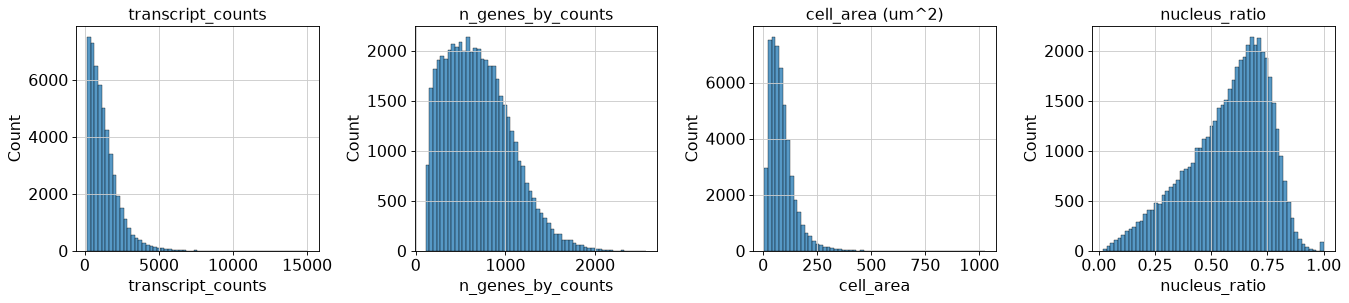

In [9]:
print("X dtype:", adata.X.dtype, "| X max:", float(adata.X.max()), "| X min:", float(adata.X.min()))
print("counts layer max:", float(adata.layers["counts"].max()),
      "(integer-valued -> raw counts)")
print("Non-integer .X values indicate the matrix is already log1p-normalized.")

fig, axes = plt.subplots(1, 4, figsize=(17, 4))
sns.histplot(adata.obs["transcript_counts"], bins=60, ax=axes[0])
axes[0].set_title("transcript_counts")
sns.histplot(adata.obs["n_genes_by_counts"], bins=60, ax=axes[1])
axes[1].set_title("n_genes_by_counts")
sns.histplot(adata.obs["cell_area"], bins=60, ax=axes[2])
axes[2].set_title("cell_area (um^2)")
sns.histplot(adata.obs["nucleus_ratio"].dropna(), bins=60, ax=axes[3])
axes[3].set_title("nucleus_ratio")
plt.tight_layout()
plt.show()

💡 **HINT.** The standard Xenium QC recipe is: drop cells with total gene count < 10, drop
genes detected in < 10 cells, then `normalize_total` + `log1p`. These files have already had
that applied — which is why the histograms above have **no long left tail of near-empty
cells** and `.X` is already normalized.

⚠️ **CHECKPOINT:** `n_genes_by_counts` should have a clear mode well above 0, and
`nucleus_ratio` (nucleus area ÷ cell area) should sit mostly between roughly **0.1 and 0.6** —
a healthy mix of cells, not cell outlines that are all-nucleus or all-cytoplasm.

## 3. Normalization, clustering and UMAP

🔬 **TASK 3.1:** Run the standard **PCA → neighbors → Leiden → UMAP** pipeline, then colour
the UMAP by your Leiden clusters, by the pre-existing `predictions` label, and by sample.

**A note on normalization.** We confirmed in Section 2 that `.X` is *already* normalized
(`normalize_total` + `log1p`), so we can go straight to dimensionality reduction. If you ever
start from raw counts instead, the one-liner recipe is:

```python
adata.X = adata.layers['counts'].copy()
sc.pp.normalize_total(adata)   # equalize sequencing depth per cell
sc.pp.log1p(adata)             # log-transform to tame highly expressed genes
```

Because the panel is small (5,101 genes) we skip highly-variable-gene selection and use all
panel genes for PCA.

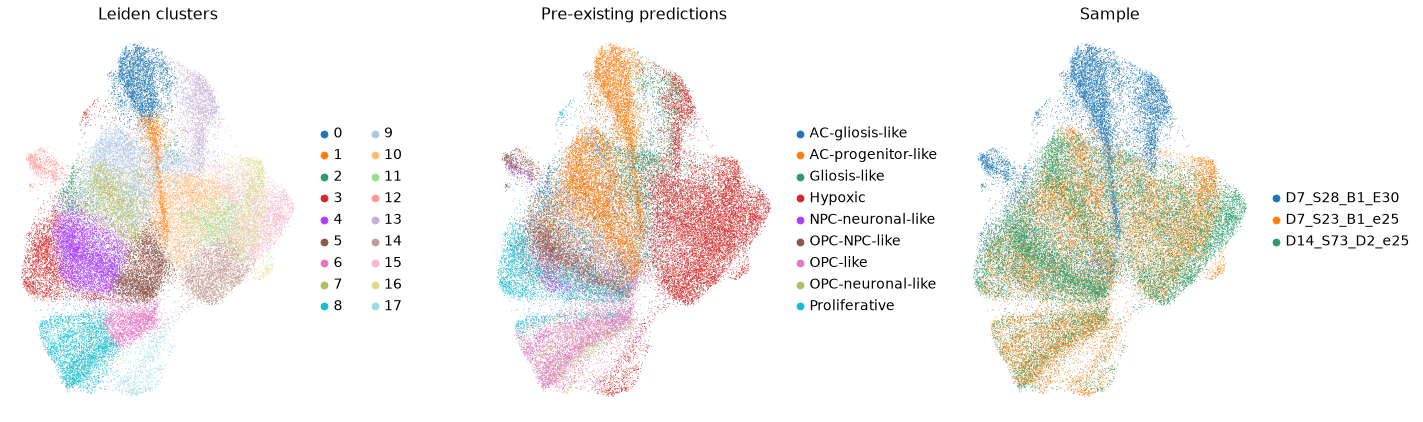

In [12]:
sc.pp.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.leiden(adata, resolution=1.0, key_added="leiden", flavor="igraph", n_iterations=2)
sc.tl.umap(adata)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
sc.pl.umap(adata, color="leiden", ax=axes[0], show=False, title="Leiden clusters")
sc.pl.umap(adata, color="predictions", ax=axes[1], show=False, title="Pre-existing predictions")
sc.pl.umap(adata, color="sample", ax=axes[2], show=False, title="Sample")
plt.tight_layout()
plt.show()

❓ **QUESTION:** Do your unsupervised Leiden clusters line up with the pre-computed
`predictions` labels? And do the three samples mix together on the UMAP, or separate into
their own islands (which would suggest a batch effect between sections)? A quick cross-tab
makes the cluster ↔ prediction correspondence concrete:

In [14]:
pd.crosstab(adata.obs["leiden"], adata.obs["predictions"])

## 4. Nuclear vs. cytoplasmic RNA content

This is something you simply **cannot do with Visium or snRNA-seq** — it only exists because
Xenium records the location of *every individual molecule*.

For each detected transcript, the Xenium pipeline stores whether that molecule physically
**overlapped the cell's nucleus** (`overlaps_nucleus`). By counting, per cell, how many of its
molecules were nuclear vs. cytoplasmic, we get each cell's **nuclear transcript fraction**.
This is biologically interesting (nascent transcripts, nuclear-retained RNAs) *and* a useful
quality signal about how cells were outlined.

🔬 **TASK 4.1:** Open the per-molecule `transcripts.parquet` table for each sample, keep only
**high-confidence, gene-targeting, assigned** molecules, and compute each cell's nuclear fraction.

💡 **HINT.** The transcript table is large, so we read only the columns we need and push the
filters (`is_gene == True`, `qv >= 20`) down into the file read itself. `qv >= 20` is Xenium's
own recommended confidence cutoff.

In [16]:
QV_CUTOFF = 20.0  # Xenium's recommended per-molecule confidence threshold

spillover_frames = []
for name, d in RAW_DIRS.items():
    tx = pq.read_table(
        d / "transcripts.parquet",
        columns=["cell_id", "overlaps_nucleus", "feature_name", "qv", "is_gene"],
        filters=[("is_gene", "=", True), ("qv", ">=", QV_CUTOFF)],
    ).to_pandas()
    tx = tx[tx["cell_id"] != "UNASSIGNED"]   # drop molecules not assigned to any cell
    tx["sample"] = name
    spillover_frames.append(tx)
    print(f"{name}: {len(tx):>10,} assigned, qv>={QV_CUTOFF:.0f}, gene-targeting transcripts")

transcripts = pd.concat(spillover_frames, ignore_index=True)
print(f"\nTotal: {len(transcripts):,} transcripts across all 3 samples")

D7_S28_B1_E30: 31,845,933 assigned, qv>=20, gene-targeting transcripts
D7_S23_B1_e25: 58,098,427 assigned, qv>=20, gene-targeting transcripts
D14_S73_D2_e25: 28,066,239 assigned, qv>=20, gene-targeting transcripts

Total: 118,010,599 transcripts across all 3 samples


Now collapse the per-molecule table to **one row per cell**: total transcripts, how many were
nuclear, and the resulting nuclear fraction. Then we attach that fraction back onto our
AnnData (matching on `sample` + `cell_id`) so we can relate it to the per-cell metadata.

In [18]:
per_cell = (
    transcripts.groupby(["sample", "cell_id"])
    .agg(n_transcripts=("overlaps_nucleus", "size"),
         n_nuclear=("overlaps_nucleus", "sum"))
    .reset_index()
)
per_cell["nuclear_fraction"] = per_cell["n_nuclear"] / per_cell["n_transcripts"]

# Attach to adata by a combined (sample, cell_id) key.
key = adata.obs["sample"].astype(str) + "::" + adata.obs["cell_id"].astype(str)
lookup = per_cell.set_index(per_cell["sample"].astype(str) + "::" + per_cell["cell_id"].astype(str))
adata.obs["n_transcripts_checked"] = key.map(lookup["n_transcripts"]).to_numpy()
adata.obs["nuclear_fraction"] = key.map(lookup["nuclear_fraction"]).to_numpy()

print(adata.obs["nuclear_fraction"].describe())

count    50595.000000
mean         0.648968
std          0.187865
min          0.000000
25%          0.543889
50%          0.696000
75%          0.790668
max          1.000000
Name: nuclear_fraction, dtype: float64


🔬 **TASK 4.2:** Visualize the nuclear fraction. First its overall distribution, then how it
relates to cell **morphology** — specifically `nucleus_ratio`, the fraction of the cell's *area*
that is nucleus. We'd expect cells whose area is mostly nucleus to also have a larger share of
their *transcripts* inside the nucleus.

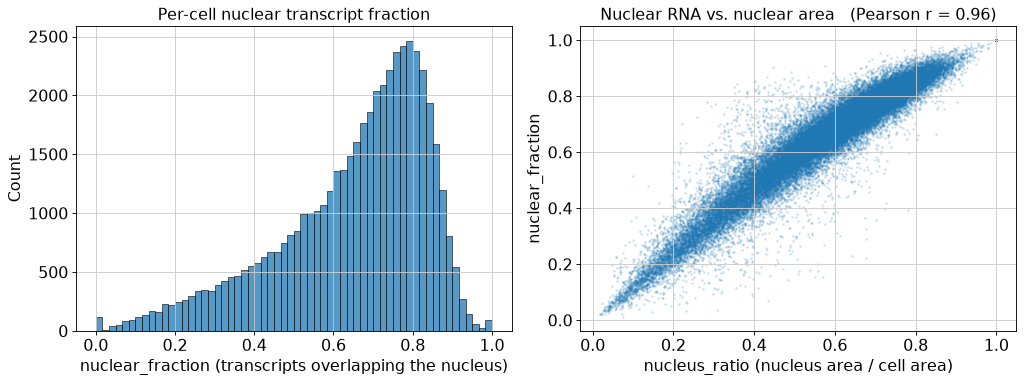

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) Distribution of the per-cell nuclear transcript fraction
sns.histplot(adata.obs["nuclear_fraction"].dropna(), bins=60, ax=axes[0])
axes[0].set_xlabel("nuclear_fraction (transcripts overlapping the nucleus)")
axes[0].set_title("Per-cell nuclear transcript fraction")

# (b) Nuclear fraction vs. morphology (nucleus area / cell area)
axes[1].scatter(adata.obs["nucleus_ratio"], adata.obs["nuclear_fraction"], s=2, alpha=0.15)
axes[1].set_xlabel("nucleus_ratio (nucleus area / cell area)")
axes[1].set_ylabel("nuclear_fraction")
r = adata.obs[["nucleus_ratio", "nuclear_fraction"]].dropna().corr().iloc[0, 1]
axes[1].set_title(f"Nuclear RNA vs. nuclear area   (Pearson r = {r:.2f})")
plt.tight_layout()
plt.show()

❓ **QUESTION:** Is the correlation between `nucleus_ratio` (a *morphology* / area measure) and
`nuclear_fraction` (an *RNA-content* measure) positive, and how strong is it? A cell can have a
large nucleus by area yet still have most of its *transcripts* in the cytoplasm — so these two
quantities are related but not identical. Think about what a cell with a **high nuclear fraction**
might be doing biologically (e.g. actively transcribing, with lots of nascent nuclear RNA).

---

### Recap
You loaded a single-cell-resolution Xenium dataset, saw how its AnnData differs from Visium
spots and snRNA-seq nuclei, ran a full QC → clustering → UMAP pipeline, and used Xenium's
unique **subcellular** information to measure nuclear vs. cytoplasmic RNA content — something
only an imaging-based, single-molecule platform can tell you.